# **Time is Money**
***Summer 2026 Data Science Project***

**Team:** Priyanka Patel, Abel Isack, Sohan Shetty, Jordan Bolesta

**Priyanka's contribution:** Hypothesis Testing to determine whether the salary difference between junior (≤5 years) and senior (≥10 years) developers is statistically significant. Includes group comparison, p-value interpretation, and boxplot visualization. Also worked in the final conclusion and helped with part of the model evaluation.

**Abel's contribution:** Data Preprocessing — loaded both the Stack Overflow Developer Survey and Kaggle Data Science Salaries datasets, filtered to relevant experience and salary columns, removed missing values, and converted columns to numeric types. Also, setup and split the data to prepare it for training the Linear Regression model.

**Sohan's contribution:** Descriptive Statistics summarizing the distribution of years of professional experience and salary. This included computing summary statistics (mean, median, standard deviation, quartiles), and visualizing the distributions of the key variables. Trained the machine model using linear regression to represent the correlation between salary and years in the profession.

**Jordan's contribution:** Correlation analysis to determine the relationship between years of experience and salary across the entire dataset. This included calculating the Pearson correlation coefficient, regression modeling, and scatterplot visualization.

### **Table of Contents**

**A.** [Introduction](#section-i-introduction)

**B.** [Data Curation](#section-ii-data-curation)

**C.** [Data Analysis](#section-iii-data-analysis)

**D.** [Machine Learning Analysis](#section-iv-machine-learning-analysis)

**E.** [Visualization](#section-v-visualization)

**F.** [Conclusion](#section-vi-conclusion)

## **Section I. Introduction**

**Main Research Question:** How does a software developer's years of professional experience affect their salary?

**Why we are choosing this dataset:** We chose these datasets because together they allow us to study how years of professional experience affects software developer salaries from different perspectives. Instead of relying on a single source, we aim to compare trends across multiple datasets and evaluate whether results remain consistent.
The Stack Overflow Developer Survey is our main dataset because it contains a large, globally representative sample of developers along with detailed information on salary and experience. This makes it well-suited for identifying general trends in the software engineering field.
The Kaggle software engineer salary dataset is used as a secondary source. It provides a cleaner, structured dataset that helps validate whether the relationship between experience and salary is consistent across different data collection methods.
Overall, using multiple datasets allows us to reduce bias from any single source and strengthens the reliability of our conclusions.


## **Section II. Data Curation**

In this section, we are going to transform our data in order to prepare it for analysis. Our goals are to:

(a) import

(b) parse

(c) organize

We import pandas, a Python library for data manipulation and analysis, 
which we will use to load, clean, and organize our datasets.

In [19]:
import pandas as pd

We load both datasets into pandas DataFrames: the Stack Overflow Developer 
Survey and the Kaggle Data Science Salaries dataset.

**Note:** The Stack Overflow dataset (`results.csv`) is sourced from [https://github.com/StackExchange/Survey/raw/refs/heads/main/packages/archive/2024/results.csv](https://github.com/StackExchange/Survey/raw/refs/heads/main/packages/archive/2024/results.csv). It was too large to upload to GitHub and must be downloaded separately and placed in the project root directory.

In [20]:
so = pd.read_csv("results.csv")
salary = pd.read_csv("ds_salaries.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'results.csv'

We keep only `YearsCodePro` and `ConvertedCompYearly` from the Stack Overflow dataset, as well as `experience_level` and `salary_in_usd` from the Salaries dataset since our research question focuses solely on experience and salary.

In [ ]:
so = so[["YearsCodePro", "ConvertedCompYearly"]]
salary = salary[["experience_level", "salary_in_usd"]]

We remove any rows with missing values in the columns we care about, 
since incomplete entries would skew our analysis.

In [ ]:
so = so.dropna(subset=["YearsCodePro", "ConvertedCompYearly"])
salary = salary.dropna(subset=["experience_level", "salary_in_usd"])

We convert the relevant columns to numeric types so they can be used in 
calculations and visualizations. The `errors="coerce"` argument turns any 
non-numeric strings into NaN, which we drop.

In [ ]:
so["YearsCodePro"] = pd.to_numeric(so["YearsCodePro"], errors="coerce")
so["ConvertedCompYearly"] = pd.to_numeric(so["ConvertedCompYearly"], errors="coerce")
salary["salary_in_usd"] = pd.to_numeric(salary["salary_in_usd"], errors="coerce")

We drop any remaining rows that became NaN after the type conversion, 
ensuring both datasets are fully clean and numeric.

In [ ]:
so = so.dropna()
salary = salary.dropna()

We verify the cleaned datasets by inspecting their structure and previewing 
the first few rows, confirming correct data types and no missing values remain.

**Legend for `experience_level`:** EN Entry-level / Junior MI Mid-level / Intermediate SE Senior-level / Expert EX Executive-level / Director

In [ ]:
print("=== Stack Overflow Dataset ===")
so.info()
print(so.head())

print("\n=== Kaggle Salaries Dataset ===")
salary.info()
print(salary.head())

=== Stack Overflow Dataset ===
<class 'pandas.DataFrame'>
Index: 22674 entries, 72 to 41187
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YearsCodePro         22674 non-null  float64
 1   ConvertedCompYearly  22674 non-null  float64
dtypes: float64(2)
memory usage: 531.4 KB
     YearsCodePro  ConvertedCompYearly
72            1.0               7322.0
374           6.0              30074.0
379           6.0              91295.0
385          17.0              53703.0
389           7.0             110000.0

=== Kaggle Salaries Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   experience_level  607 non-null    str  
 1   salary_in_usd     607 non-null    int64
dtypes: int64(1), str(1)
memory usage: 9.6 KB
  experience_level  salary_in_usd
0             

We save the cleaned datasets as CSV files so that other group members can 
load them directly.

In [ ]:
so.to_csv("so_clean.csv", index=False)
salary.to_csv("salary_clean.csv", index=False)

## **Section III. Data Analysis**
### **Method I. Hypothesis Testing**

We aim to determine whether there is a statistically significant difference in salary between developers with low and high years of professional experience.

Specifically, we compare junior developers (≤ 5 years of experience) and senior developers (≥ 10 years of experience).

**Hypotheses**

We define the hypotheses as follows:

Null Hypothesis (H₀): There is no difference in average salary between junior and senior developers.

Alternative Hypothesis (H₁): There is a difference in average salary between junior and senior developers.

In [ ]:
so = pd.read_csv("so_clean.csv")

In [ ]:
# We use the cleaned Stack Overflow dataset and split it into two groups based on YearsCodePro.
junior = so[so["YearsCodePro"] <= 5]["ConvertedCompYearly"]
senior = so[so["YearsCodePro"] >= 10]["ConvertedCompYearly"]

# We remove any missing values to ensure the test is valid.

junior = junior.dropna()
senior = senior.dropna()
#We also check the sample sizes:

print("Junior sample size:", len(junior))
print("Senior sample size:", len(senior))

Junior sample size: 8025
Senior sample size: 9885


**Hypothesis Testing**

We perform an independent two-sample t-test to compare the mean salaries of the two groups.

This test is appropriate because:

We are comparing two independent samples (junior vs. senior developers)
We allow for the possibility of unequal variances between the two groups (equal_var=False)

We use a significance level of α = 0.05. If the p-value is less than 0.05, we reject the null hypothesis.

In [ ]:
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(junior, senior, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: -21.16784319739279
P-value: 3.544404811278394e-98


**Conclusion**

The t-test produced a very large negative t-statistic and a p-value far below our significance threshold of α = 0.05. This means we reject the null hypothesis.

There is a statistically significant difference in salary between junior developers (≤ 5 years of experience) and senior developers (≥ 10 years of experience). Senior developers earn meaningfully more on average, providing strong statistical evidence that years of professional experience has a real effect on compensation — not one attributable to random chance.

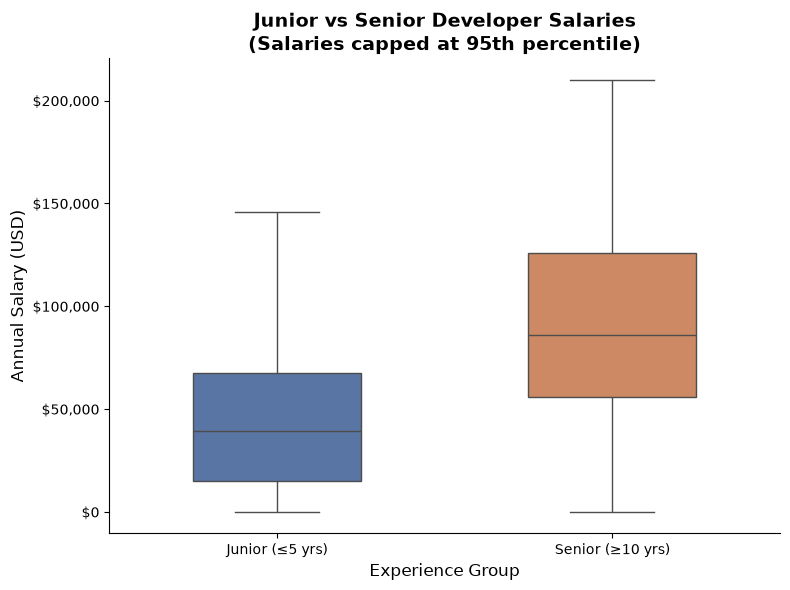

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cap salaries at the 95th percentile to reduce the effect of extreme outliers
salary_cap = so["ConvertedCompYearly"].quantile(0.95)

junior_capped = junior[junior <= salary_cap]
senior_capped = senior[senior <= salary_cap]

plot_df = pd.DataFrame({
    "Salary (USD)": pd.concat([junior_capped, senior_capped]),
    "Experience Group": ["Junior (≤5 yrs)"] * len(junior_capped) + ["Senior (≥10 yrs)"] * len(senior_capped)
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    x="Experience Group",
    y="Salary (USD)",
    hue="Experience Group",
    data=plot_df,
    palette={"Junior (≤5 yrs)": "#4C72B0", "Senior (≥10 yrs)": "#DD8452"},
    width=0.5,
    legend=False,
    showfliers=False,
    ax=ax
)
ax.set_title("Junior vs Senior Developer Salaries\n(Salaries capped at 95th percentile)", fontsize=14, fontweight="bold")
ax.set_xlabel("Experience Group", fontsize=12)
ax.set_ylabel("Annual Salary (USD)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

### **Method II. Correlation Testing**

The goal here is to determine if there is a quantitative relationship between the developer's years of professional experience and their total annual salaries. 

We are using the Pearson Correlation Coefficient to measure the linear strength between YearsCodePro and ConvertedCompYearly. Since both of these variables are numeric, this method is the best to see how they relate. 

In [ ]:
# calc correlation:
correlation = so['YearsCodePro'].corr(so['ConvertedCompYearly'], method='pearson')
print(f"Pearson Correlation Coefficiant: {correlation:.4f}")

Pearson Correlation Coefficiant: 0.1344


**Correlation Scatter Plot**

We plotted this data on a scatter plot and added a trendline. This makes it a lot easier to see the connection: the dots show the raw data, and the line gives us a clear look at the direction the data is heading. 

__Note:__ For better visual clarity, the y-axis was capped at $1.5 million. While the Pearson correlation was calculated using the full, unedited dataset, the visualization was capped to focus on the trend for the majority of the dataset, while excluding the extreme, non-representive outliers.

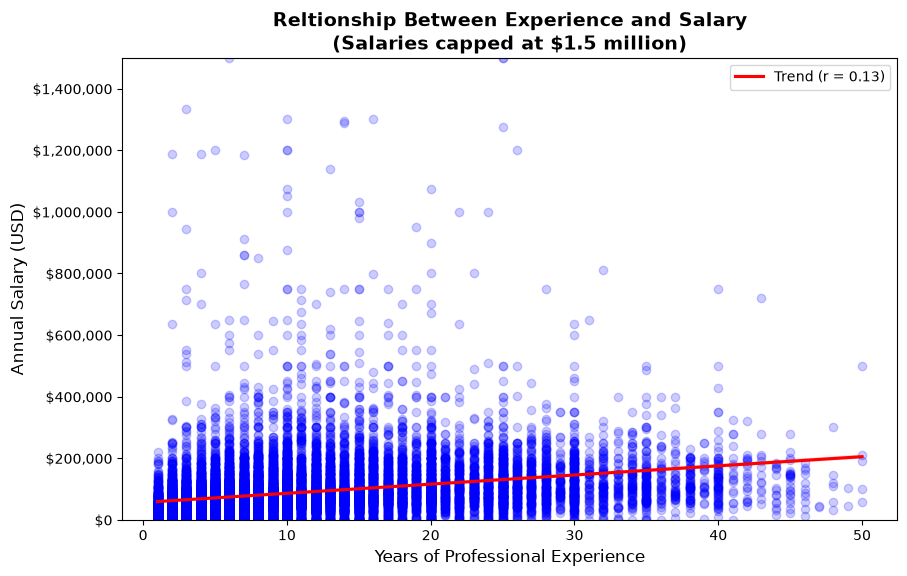

In [ ]:
import matplotlib.ticker as ticker

# make it bigger so its easier ot read:
plt.figure(figsize=(10, 6))

# create sctter plot
sns.regplot(
    x = 'YearsCodePro', 
    y = 'ConvertedCompYearly',
    data = so,
    scatter_kws = {'alpha':0.2, 'color':'blue'},
    line_kws={'color':'red', 'label':f'Trend (r = {correlation:.2f})'}

)

# cap at 1,5 mil for y:
plt.ylim(0, 1500000)

# add dollar signs, commas, and full nums to y labels:
formatting = ticker.StrMethodFormatter('${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatting)

plt.title("Reltionship Between Experience and Salary\n(Salaries capped at $1.5 million)", fontsize=14, weight='bold')
plt.xlabel("Years of Professional Experience", fontsize=12)
plt.ylabel("Annual Salary (USD)", fontsize=12)
plt.legend()
plt.show()

**Conclusion**

Our analysis resulted in a Pearson correlation coefficient of 0.13, which indicated a very weak positive relationship. It suggests that while there is a slight upward tendency, years of professional experience are not a reliable predictor of salary across the entire dataset.

These findings appear different from our t-test results because the t-test is focused on two specific, distant groups, juniors and seniors, and confirmed a statistically significant salary gap between them. In contrast, the correlation analysis examines the entire career span at once. This shows that the "seniority jump" is clear when comparing the two groups, but the relationship becomes more complex when looking at the entire dataset. 

The regression line does show a slight upward trend, but the data points are spread so widely that other factors are influencing the variations in salary. Pay could be influenced by a broader set of variables, rather than experience alone. 


### **Method III. Descriptive Statistics**

The goal here is to summarize and describe the key variables in our dataset — years of professional experience (`YearsCoding`) and annual salary (`ConvertedCompYearly`) — before drawing any inferential conclusions.

We compute summary statistics (such as the mean, median, standard deviation, and quartiles) to understand the central tendency and spread of each variable, and we visualize their distributions to identify skew, outliers, and overall shape.

To begin, we read the data set that we are summarizing and describing.

In [ ]:
import pandas as pd

sal_clean = pd.read_csv('salary_clean.csv')
print(sal_clean.head())

  experience_level  salary_in_usd
0               MI          79833
1               SE         260000
2               SE         109024
3               MI          20000
4               SE         150000


Then, we compute summary statistics for `YearsCodePro` and `ConvertedCompYearly`.

In [ ]:
sal_stats = sal_clean.groupby('experience_level')['salary_in_usd'].agg(['mean', 'median', 'std', 'count'])
print(sal_stats)

                           mean    median            std  count
experience_level                                               
EN                 61643.318182   56500.0   44395.541126     88
EX                199392.038462  171437.5  117071.255697     26
MI                 87996.056338   76940.0   63901.057478    213
SE                138617.292857  135500.0   57691.978337    280


Finally, we visualize the distribution of the key variables.

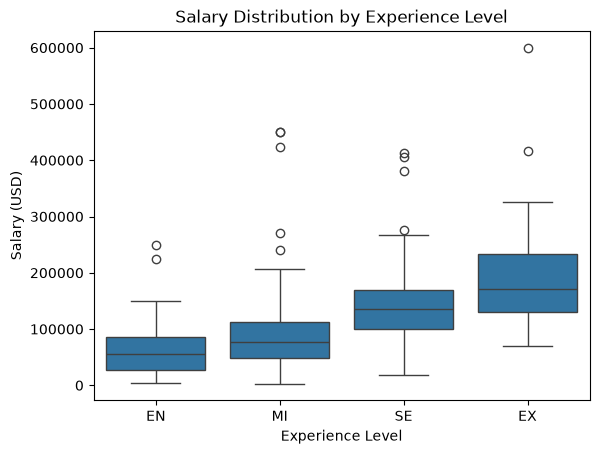

In [ ]:
import seaborn as sns

sns.boxplot(x='experience_level', y='salary_in_usd', data=sal_clean, order=['EN', 'MI', 'SE', 'EX'])
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()

**Conclusion**

Based on the descriptive statistics, the Executive-level group had only 26 entries compared to 213 for Mid-level and 280 for Senior. From this we can assume the executive salary data is 
less reliable and harder to generalize. Furthermore, the standard deviation for Executive-level is wide at $117,071, by far the widest of any group. This tells us there is enormous variability in what an executive-level engineer actually makes a year, 
making it hard to name a typical exec-level salary. Finally, across all experience levels the mean and median are relatively close to each other, suggesting the distributions are not too skewed and outliers are not super apparent.


## **Section IV. Machine Learning Analysis**
Now that we have explored the distribution of salaries and proven that a statistically significant difference exists between experience groups through hypothesis testing, we want to construct a predictive tool. We will train a Linear Regression model using the clean Stack Overflow dataset (`so_clean.csv`) to predict a software developer's yearly compensation based on their years of professional code experience.

**Step 1: Setup and Data Splitting**

To begin, we import the necessary modules.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

To ensure our model generalizes well to unseen data, we will split our dataset into a Training set **(80%)** and a Test set **(20%)** using `train_test_split`.

In [ ]:
so = pd.read_csv("so_clean.csv")

# Define features (X) and target (y)
X = so[["YearsCodePro"]] 
y = so["ConvertedCompYearly"]

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 18139, Test samples: 4535


**Step 2: Training the Model**

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2970.99]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsCodePro']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.58e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


**Step 3: Model Evaluation**

In [28]:
y_pred = model.predict(X_test)        
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.4f}")
print(f"Model Coefficients: {model.coef_}, Intercept: {model.intercept_}")

Mean Squared Error: 74376028711.73
R-squared: 0.0083
Model Coefficients: [2970.99034705], Intercept: 55798.58208467807


## **Section V: Visualization**

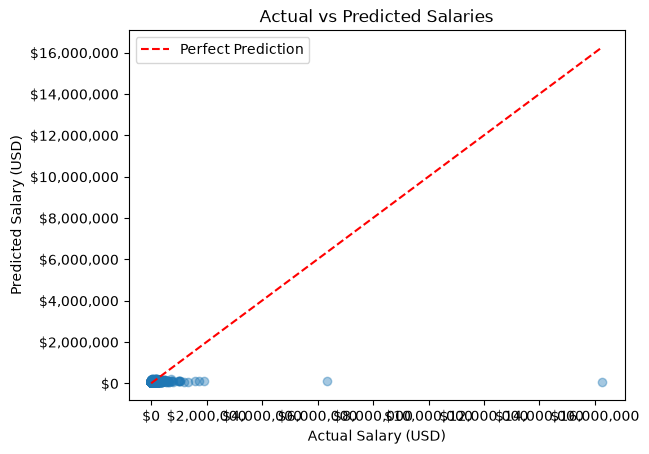

In [33]:
import matplotlib.ticker as ticker

plt.scatter(y_test, y_pred, alpha=0.4) 
plt.plot( [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction' ) 
plt.xlabel("Actual Salary (USD)") 
plt.ylabel("Predicted Salary (USD)") 
plt.title("Actual vs Predicted Salaries")
plt.legend()
formatter = ticker.StrMethodFormatter('${x:,.0f}')

plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

Text(0.5, 1.0, 'Linear Regression Predictions')

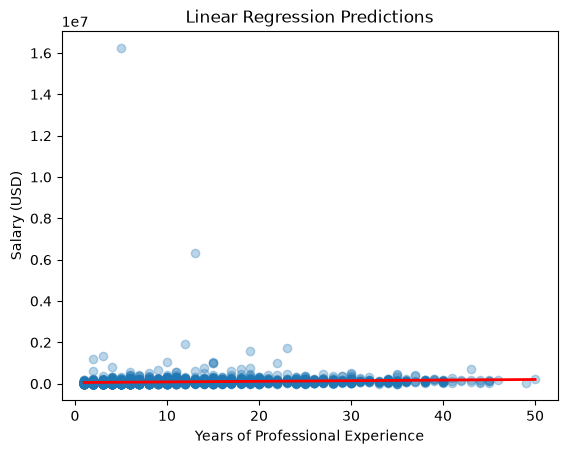

In [30]:
#Regression Line on Test Data:
plt.scatter(X_test, y_test, alpha=0.3) 
order = X_test.iloc[:,0].argsort() 
plt.plot( X_test.iloc[order], y_pred[order], color='red', linewidth=2 ) 
plt.xlabel("Years of Professional Experience") 
plt.ylabel("Salary (USD)") 
plt.title("Linear Regression Predictions")

Text(0.5, 1.0, 'Residual Plot')

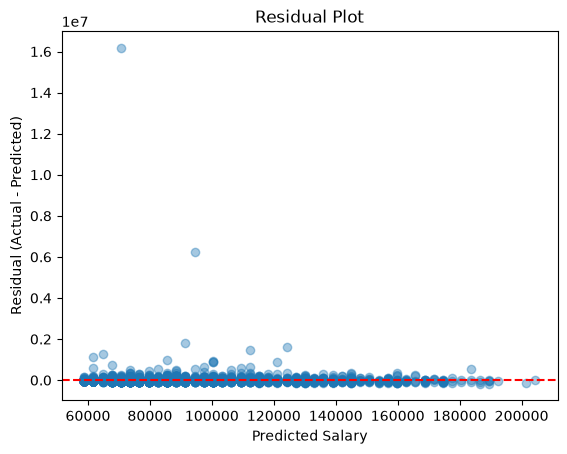

In [25]:
#Residual Plot:
error_vals = y_test - y_pred
plt.scatter(y_pred, error_vals, alpha=0.4) 
plt.axhline(0, color='red', linestyle='--') 
plt.xlabel("Predicted Salary") 
plt.ylabel("Residual (Actual - Predicted)") 
plt.title("Residual Plot")

Text(0.5, 1.0, 'Distribution of Prediction Errors')

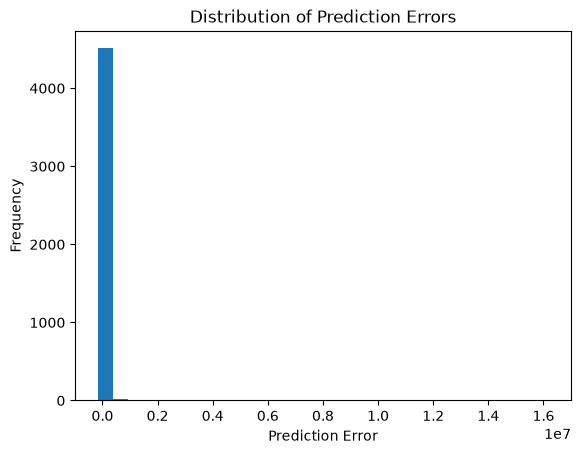

In [26]:
#Histogram of Prediction Errors:
plt.hist(error_vals, bins=30) 
plt.xlabel("Prediction Error") 
plt.ylabel("Frequency") 
plt.title("Distribution of Prediction Errors")

## **Section VI: Conclusion**